#Section 1: Import Libraries


In this section the required libraries for data analysis visualization machine learning and statistical testing are imported. Pandas and NumPy are used for data manipulation Matplotlib and Seaborn are used for visualization Scikit Learn is used for model development and Statsmodels is used for time series analysis.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

#Section 2: Dataset Loading and Understanding


The dataset is loaded and explored to understand its structure dimensions and available features. Understanding the dataset before analysis helps identify useful variables and potential data quality issues.

2.1 Uploading and Loading the Dataset


The dataset must first be loaded into memory so that it can be explored and analyzed.


- Uploads the dataset file.
- Reads the CSV file into a DataFrame.
- Displays the first five rows.


In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

df.head()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025 (1).csv


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 2.2 Dataset Shape

The shape of the dataset helps determine the number of records and features available for analysis.


Returns the total number of rows and columns in the dataset.

In [ ]:
df.shape

(2640, 12)

## 2.3 Column Names

Examining column names helps identify the available variables and understand the dataset contents.


Displays all feature names present in the dataset.

In [ ]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

## 2.4 Data Types

Understanding data types helps identify numerical and categorical variables before preprocessing.


Displays data types non null counts and memory usage information.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


## 2.5 Statistical Summary

A statistical summary provides information about the distribution of numerical features.


Displays count mean standard deviation minimum maximum and quartile values for numerical features.

In [ ]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# Section 3: Data Quality Checks

Data quality checks help identify missing values and duplicate records before further analysis.

## 3.1 Missing Values

Missing values can affect model performance and should be identified before preprocessing.


Counts missing values in each column.

In [ ]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


## 3.2 Duplicate Records

Duplicate records may introduce bias and should be checked before model training.


Returns the number of duplicate rows present in the dataset.

In [ ]:
df.duplicated().sum()

np.int64(0)

# Section 4: Exploratory Data Analysis

EDA helps understand patterns trends and relationships between variables in the dataset.

## 4.1 Deliveries by Model

This visualization compares delivery performance across Tesla models.


Calculates average deliveries for each model and visualizes them using a bar chart.

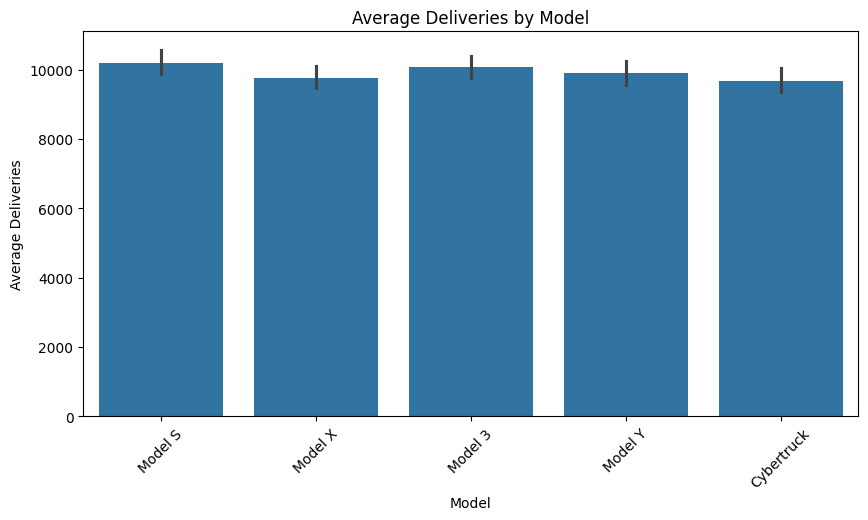

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='Estimated_Deliveries',
    data=df,
    estimator=np.mean
)

plt.title("Average Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Average Deliveries")
plt.xticks(rotation=45)

plt.show()

## 4.2 Deliveries by Region

This visualization compares delivery performance across geographic regions.


Calculates average deliveries for each region and displays them using a bar chart.

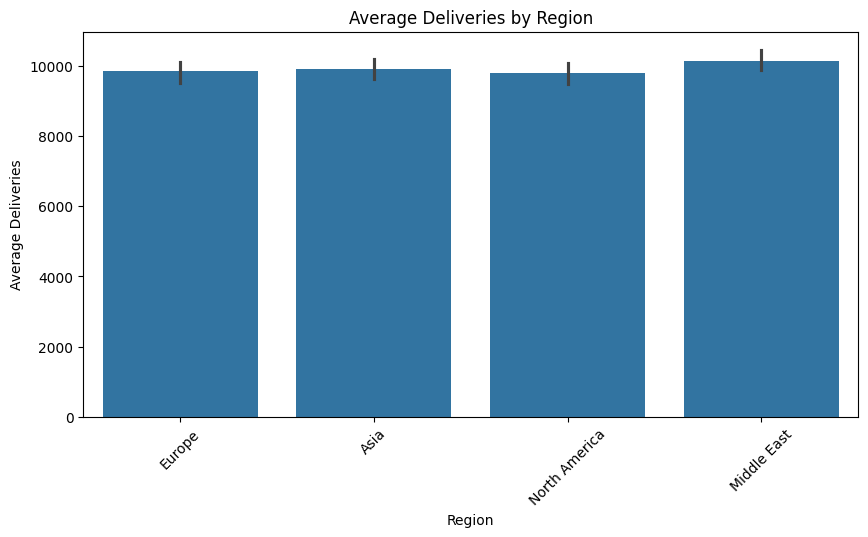

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df,
    estimator=np.mean
)

plt.title("Average Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Average Deliveries")
plt.xticks(rotation=45)

plt.show()

## 4.3 Correlation Heatmap

A correlation heatmap is used to understand the relationship between numerical variables in the dataset. Features with stronger correlations may provide useful information for prediction and help identify important patterns in the data.

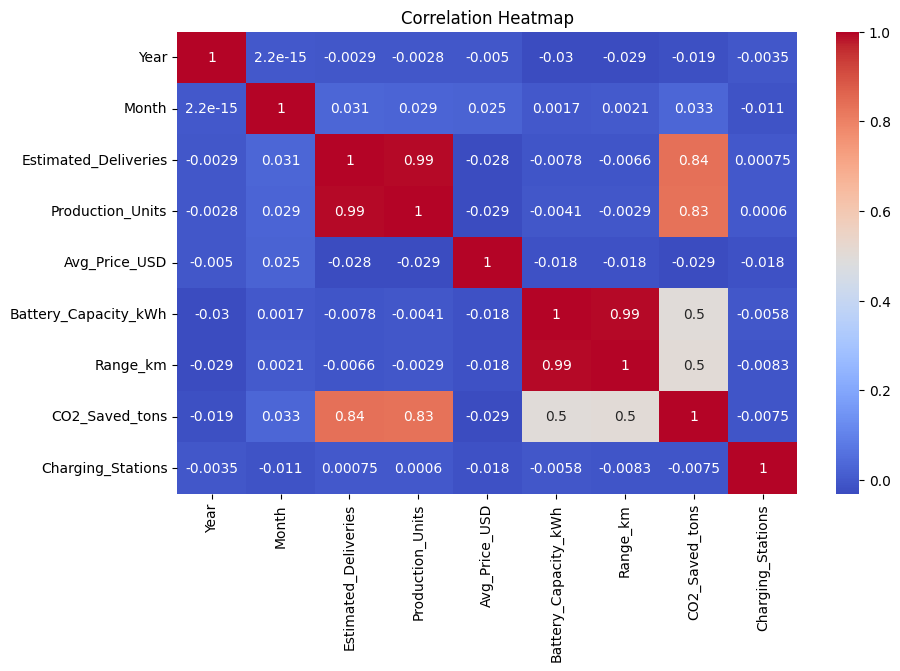

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

## 4.4 Production vs Deliveries Scatter Plot

A scatter plot helps visualize the relationship between production volume and estimated deliveries. This allows us to identify whether higher production levels are associated with higher delivery numbers.

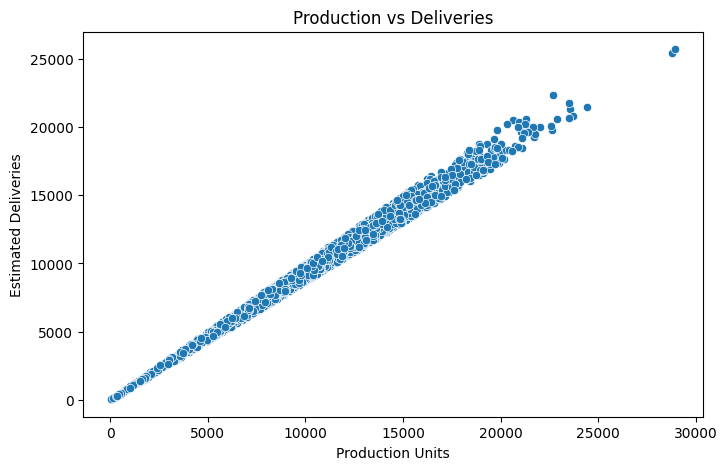

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Production_Units',
    y='Estimated_Deliveries'
)

plt.title("Production vs Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.show()

## 4.5 Time Trend Line

Time based analysis helps identify trends and changes in deliveries over different years. Understanding these trends is important before creating forecasting models.

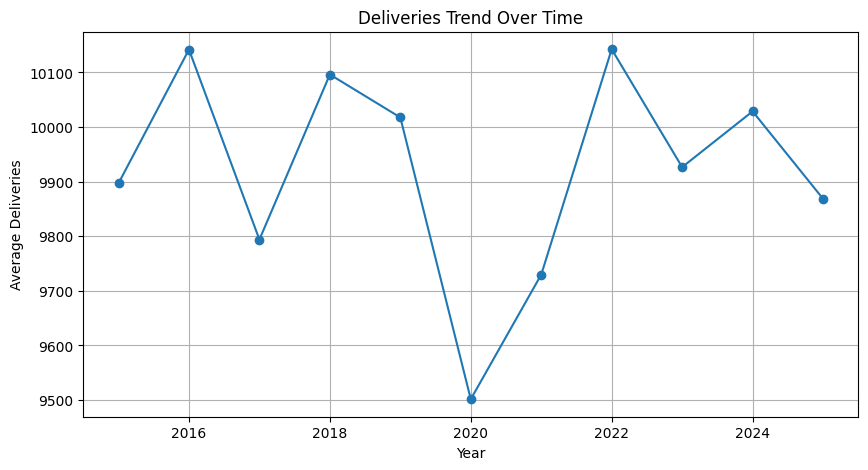

In [ ]:
yearly_deliveries = df.groupby('Year')['Estimated_Deliveries'].mean()

plt.figure(figsize=(10,5))

plt.plot(
    yearly_deliveries.index,
    yearly_deliveries.values,
    marker='o'
)

plt.title("Deliveries Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Deliveries")
plt.grid(True)

plt.show()

# Section 5: Label Encoding

Machine learning models require numerical inputs. Label Encoding converts categorical variables into numerical values while preserving the information contained in those categories.

In [ ]:
le = LabelEncoder()

df['Region'] = le.fit_transform(df['Region'])
df['Model'] = le.fit_transform(df['Model'])
df['Source_Type'] = le.fit_transform(df['Source_Type'])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


# Section 6: Feature Engineering

Feature engineering is used to create additional features from existing data that may help improve model performance. In this section two new features are created. Deliveries_Lag1 stores the previous delivery value while Rolling_Mean_3 calculates the average deliveries over the previous three observations. These features help capture historical patterns and trends in the data.

## 6.1 Deliveries Lag Feature

The lag feature represents the delivery value from the previous observation. Historical values often contain useful information that can help predict future deliveries.

In [ ]:
df['Deliveries_Lag1'] = (
    df['Estimated_Deliveries']
    .shift(1)
)

df['Deliveries_Lag1'].fillna(
    df['Deliveries_Lag1'].mean(),
    inplace=True
)

df[['Estimated_Deliveries', 'Deliveries_Lag1']].head()

,Estimated_Deliveries,Deliveries_Lag1
0,17646,9924.959454
1,3797,17646.000000
2,8411,3797.000000
3,6555,8411.000000
4,12374,6555.000000


## 6.2 Rolling Mean Feature

The rolling mean feature calculates the average deliveries over the previous three observations. This helps smooth short term fluctuations and capture broader trends within the dataset.

In [ ]:
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

df['Rolling_Mean_3'].fillna(
    df['Rolling_Mean_3'].mean(),
    inplace=True
)

df[['Estimated_Deliveries', 'Rolling_Mean_3']].head()

,Estimated_Deliveries,Rolling_Mean_3
0,17646,9923.677407
1,3797,9923.677407
2,8411,9951.333333
3,6555,6254.333333
4,12374,9113.333333


## 6.3 Feature Verification

After creating the new features the dataset is checked to ensure that the engineered columns have been added successfully and contain valid values.

In [ ]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Deliveries_Lag1,Rolling_Mean_3
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,9924.959454,9923.677407
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,17646.000000,9923.677407
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,3797.000000,9951.333333
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,8411.000000,6254.333333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,6555.000000,9113.333333


# Section 7: Chronological Train Test Split

Since the dataset contains time related information the data is split chronologically rather than randomly. The first 80 percent of observations are used for training and the remaining 20 percent are used for testing. This approach prevents future information from leaking into the training data.

In [ ]:
X = df.drop('Estimated_Deliveries', axis=1)
y = df['Estimated_Deliveries']

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (2112, 13)
Testing Shape: (528, 13)


# Section 8: Linear Regression Model

Linear Regression is used as the baseline model for predicting estimated deliveries. The model learns the relationship between the input features and the target variable and generates predictions for the test dataset.

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, lr_pred)
rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
r2 = r2_score(y_test, lr_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 310.3345215398842
RMSE: 375.5646664534478
R2 Score: 0.9908058721380986


## 8.1 Actual vs Predicted Plot

This visualization compares actual delivery values with predicted delivery values. A strong alignment between the two indicates better model performance.

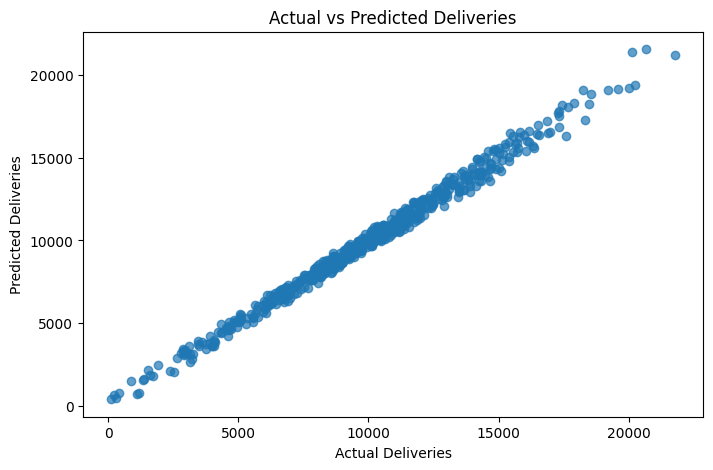

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    lr_pred,
    alpha=0.7
)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")

plt.show()

# Section 9: 5 Fold Cross Validation

Cross validation evaluates model performance across multiple subsets of the dataset. This provides a more reliable estimate of model performance than a single train test split.

In [ ]:
cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Fold Scores:")
print(cv_scores)

print("\nMean R2 Score:")
print(cv_scores.mean())

Fold Scores:
[0.99064898 0.99046596 0.98949291 0.99051101 0.99080587]

Mean R2 Score:
0.9903849476659861


# Section 10: Random Forest with Hyperparameter Tuning

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy. GridSearchCV is used to identify the best combination of model parameters.

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 50}


## 10.1 Model Evaluation

The best model identified by GridSearchCV is evaluated using MAE RMSE and R² on the test dataset.

In [ ]:
best_rf = grid_search.best_estimator_

rf_pred = best_rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

MAE: 303.85833333333335
RMSE: 388.5512760612014
R2 Score: 0.99015903323468


# Section 11: Feature Importance Analysis

Feature importance helps identify which variables contribute most to the predictions generated by the Random Forest model.

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

importance_df

,Feature,Importance
4,Production_Units,0.990055
8,CO2_Saved_tons,0.002163
7,Range_km,0.001221
5,Avg_Price_USD,0.001040
10,Charging_Stations,0.001004
12,Rolling_Mean_3,0.000955
11,Deliveries_Lag1,0.000923
0,Year,0.000888
1,Month,0.000668
3,Model,0.000357


## 11.1 Feature Importance Visualization

The top ten most important features are visualized to better understand their contribution to model predictions.

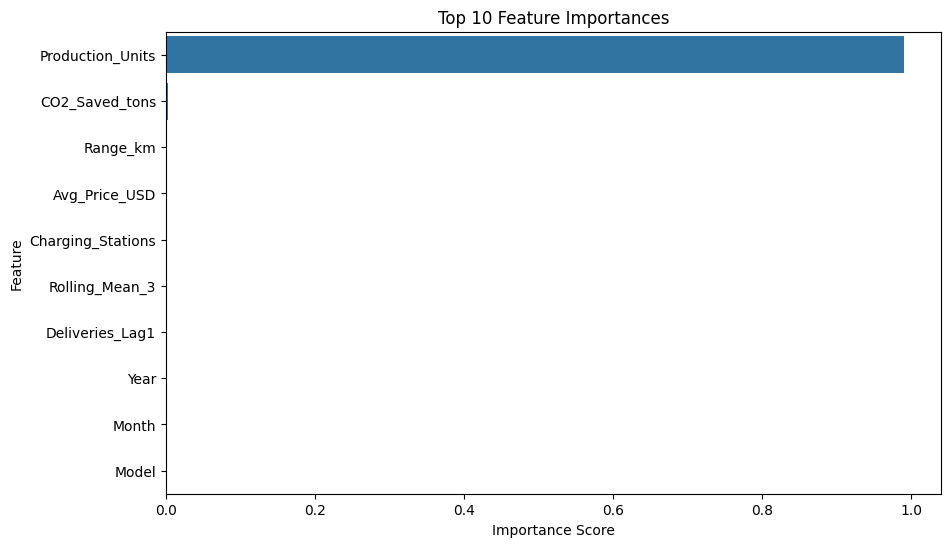

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

# Section 12: Augmented Dickey Fuller Test

The Augmented Dickey Fuller test is used to determine whether the Estimated Deliveries time series is stationary. Stationarity is an important assumption in many forecasting techniques.

In [ ]:
adf_result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic:", adf_result[0])
print("P Value:", adf_result[1])

ADF Statistic: -53.82661259715622
P Value: 0.0


## 12.1 Interpretation

The p value from the ADF test is used to determine whether the series is stationary or non stationary.

In [ ]:
if adf_result[1] < 0.05:
    print("The series is stationary because the p value is less than 0.05")
else:
    print("The series is non stationary because the p value is greater than 0.05")

The series is stationary because the p value is less than 0.05


# Section 13: Forecast Table

A comparison table is created to evaluate the difference between actual and predicted delivery values for the first twenty test observations.

In [ ]:
forecast_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': rf_pred
})

forecast_df['Error_%'] = (
    np.abs(
        forecast_df['Actual'] -
        forecast_df['Predicted']
    )
    / forecast_df['Actual']
) * 100

display(forecast_df.head(20))

,Actual,Predicted,Error_%
0,11974,11244.76,6.090195
1,9189,8947.18,2.631625
2,15956,16791.60,5.236901
3,10336,10896.56,5.423375
4,15152,15868.72,4.730201
5,4224,4014.38,4.962595
6,8475,8863.10,4.579351
7,4093,3817.50,6.731004
8,2972,3149.94,5.987214
9,8208,8202.68,0.064815


# Section 14: Model Comparison

The performance of Linear Regression and Random Forest models is compared using common regression evaluation metrics.

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R2 Score': [r2, rf_r2]
})

comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,310.334522,375.564666,0.990806
1,Random Forest,303.858333,388.551276,0.990159


# Section 15: Conclusion

In this project Tesla delivery and production data was analyzed using a complete machine learning workflow. Data exploration preprocessing feature engineering model training cross validation hyperparameter tuning feature importance analysis and stationarity testing were performed. Linear Regression and Random Forest models were evaluated and compared using multiple performance metrics. The project demonstrates how machine learning techniques can be used to analyze historical business data and generate accurate delivery predictions.